# Model selection & Regularized regression

## Data set 
The file kaiser.csv contains a subset of data from the Child Health and Development Studies, which investigate a range of topics. One study considered all pregnancies between 1960 and 1967 among women in the Kaiser Foundation Health Plan in the San Francisco East Bay area. Here, we look at the predictor of birth weight of babies, measured in pounds, as well as the occurrence of complications in the first 3 month. 

The data frame stored in kaiser.csv contains the variables: 
- age:          Age of the mom at time of birth
- smoke:        Is the mom a smoker / non-smoker? 
- hospital:     Which hospital was the birth at? Oakland, SanFrancisco, WalnutCreek, SanJose, and Richmond.
- gestation:    Gestation period (length of pregnancy) [days]
- parity:       1: child the first born 0: Child has older siblings 
- weight:       Weight of the baby [pounds].  
- complication: Was there a complication within the first 3 month of pregnancy (0: No 1:Yes) 

## Preliminaries
We have set up the environment by importing pandas, seaborn, numpy, scipy.optimize and matplotlib. 
We have added the regression functions for multiple and logistic regression from the last homeworks. 


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import scipy.optimize as so
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
def multRegPredict(b,D,xname,returnDeriv=False):
    """Model prediction function for multiple regression.
    If returnDeriv is True, it returns the derivative of the predicted values with respect to the parameters (i.e., the Jacobian matrix).

    Args:
        b (array): Q+1 regression coefficients for Q variables
        D (pd.DataFrame): Data frame
        xname (list): Names of the Q explanatory variables
    Returns:
        yp (array): predicted y-values
        deriv (np.array,optional): derivative of predicted values with respect to the parameters (N x K matrix)
    """
    yp=np.ones(len(D.index))*b[0]        # Intercept
    for i in range(len(xname)):
        yp=yp+D[xname[i]].values*b[i+1]         # Add each regression value
    if returnDeriv:
        deriv = np.ones((len(D.index),1))
        for i in range(len(xname)):
            deriv = np.c_[deriv,D[xname[i]]]         # Add each regression value
        return yp,deriv
    return yp

def logisticRegPredict(b,D,xname,returnDeriv=False):
    """Model prediction function for multiple regression.
    If returnDeriv is True, it returns the derivative of the predicted values with respect to the parameters (i.e., the Jacobian matrix).

    Args:
        b (array): Q+1 regression coefficients for Q variables
        D (pd.DataFrame): Data frame
        xname (list): Names of the Q explanatory variables
    Returns:
        yp (array): predicted y-values
        deriv (np.array,optional): derivative of predicted values with respect to the parameters (N x K matrix)
    """
    N = len(D.index)
    Q=len(xname)
    yp=np.ones((N,))*b[0]       # Start out with the intercept
    for i in range(Q):
        yp=yp+D[xname[i]].values*b[i+1]        # Add the prediction of each regressor seperately
    p = np.exp(yp)/(1+np.exp(yp))
    p = p.clip(1e-12,1-(1e-12))
    if returnDeriv:
        deriv = np.ones((len(D.index),1))
        for i in range(len(xname)):
            deriv = np.c_[deriv,D[xname[i]]]         # Add each regression value
        # Apply chain rule: The derivative of the logistic function with respect to the linear predictor is p*(1-p)
        deriv = deriv * (p * (1-p))[:, np.newaxis]
        return p,deriv
    return p

"""
Loss functions
"""
def RSSloss(b,y,predictfcn,args=(), returnDeriv=False):
    """Loss function for regression based on the residual sum of squares (RSS).

    Args:
        b (array): Parameters of the model
        y (array): Actual response variable values
        predictfcn (function): Function that takes (b, *args) and returns predicted
        args (tuple): Additional arguments to the prediction function
        returnDeriv (bool): If True, also return the gradient of the loss with respect

    Returns:
        loss (float): The residual sum of squares
        grad (array, optional): The gradient of the loss with respect to the parameters (if returnDeriv is True)
    """
    if (returnDeriv):
        predY,deriv = predictfcn(b,*args,returnDeriv=True)
        res = np.array(y-predY)
        rss = sum(res**2)
        # The derivative of the RSS with respect to b
        grad = -2 * np.sum(res.reshape(-1,1) * deriv,axis=0)
        return rss,grad
    predY = predictfcn(b,*args)
    res = y-predY
    rss = sum(res**2)
    return rss


def LogisticLoss(b,y,predictfcn,args=(),returnDeriv=False):
    if (returnDeriv):
        predY,deriv = predictfcn(b,*args,returnDeriv=True)
        loss = np.sum(-y*np.log(predY)-(1-y)*np.log(1-predY))
        dLdp = -(y.values-predY)/(predY*(1-predY))
        grad = np.sum(dLdp.reshape(-1,1) * deriv,axis=0)
        return loss.sum(),grad
    predY = predictfcn(b,*args)
    loss = np.sum(-y*np.log(predY)-(1-y)*np.log(1-predY))
    return loss

"""
Fitting functions
"""
def fit_multReg(D,y,xname=[],figure=True,b0=[]):
    """Fits a multiple regression loss function

    Args:
        D (pd.DataFrame): Pandas data frame with explanatory variables
        y (ndarray): Dependent variable
        xname (list): List of strings with names of explanatory variables
        figure (int): Plot figure? Defaults to 0.
        b0 (np.ndarray). Initial guess for the parameter vector

    Returns:
        R2: Fitted R2 value
        b: Fitted
    """
    k=len(xname)+1
    if (len(b0)!=k):
        b0=np.zeros((k,))
    RES = so.minimize(RSSloss,b0,args=(y,multRegPredict,(D,xname),True),jac=True)
    b=RES.x # Results
    TSS = sum((y-np.mean(y))**2)
    yp = multRegPredict(b,D,xname)
    RSS = sum((y-yp)**2)
    R2 = 1-RSS/TSS
    if (k==2 and figure):
        fig = plt.figure()
        ax = fig.add_subplot(1,1,1)
        ax.scatter(D[xname[0]],y)
        xRange=[min(D[xname[0]]),max(D[xname[0]])]
        xp=np.arange(xRange[0],xRange[1],(xRange[1]-xRange[0])/50)
        yp=b[0]+b[1]*xp
        ax.plot(xp,yp,'r-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    return (b,R2)

def fit_logisticReg(D,y,xname,figure=True,b_init=[]):
    """Fits a multiple regression loss function

    Args:
        D (pd.DataFrame): Pandas data frame with explanatory variables
        y (ndarray): Dependent variable
        xname (list): List of strings with names of explanatory variables
        figure (bool): Plot figure? Defaults to False.
        b0 (np.ndarray). Initial guess for the parameter vector

    Returns:
        b: Fitted
        ll: loglikihood of the fit
    """
    k=len(xname)+1
    if (len(b_init)!=k):
        b_init=np.zeros(k)
    RES = so.minimize(LogisticLoss,b_init,args=(y,logisticRegPredict,(D,xname),True),jac=True)
    b = RES.x
    ll = -RES.fun # Negative function value is the log likelihood
    p = logisticRegPredict(b,D,xname)
    if (k==2 and figure):
        fig = plt.figure()
        ax = fig.add_subplot(1,1,1)
        ax.scatter(D[xname[0]],y)
        xRange=[min(D[xname[0]]),max(D[xname[0]])]
        xp=np.arange(xRange[0],xRange[1],(xRange[1]-xRange[0])/50)
        yp=b[0]+b[1]*xp
        pp=np.exp(yp)/(1+np.exp(yp))
        ax.plot(xp,pp,'r-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    return (b,ll)

## Task 1: Multiple regression with discrete variables 
### Question 1.1 
Create a dummy variable for Smoker / Non-smoker. Set the value for “Smoker” to 1 and for “Non-smoker” to 0. Estimate a regression model with the dummy variable as a regressor *and birth weight as the response variable.* Use the RSS as the loss function. 

Report the value of the intercept and slope. 

Written answer: What does the intercept and slope value indicate? 


In [3]:
df = pd.read_csv("kaiser.csv")
df['smokeI'] = np.double(df['smoke'] == 'smoker')
b, R2 = fit_multReg(df, df['weight'], ['smokeI'], figure=False)
print(b)

[ 7.68827818 -1.20831337]


>The intercept indicates that the average birth weight for non-smoker mothers is 7.69 lbs. The slope indicates that the average birth weight for smoker mothers is 1.21 lbs lower than non-smoker mothers.

### Question 1.2 
Make a boxplot of hospital on the x-axis and birthweight on the y-axis (see HW2 for an example). Which hospital has the lowest overall birth weight?  

Text(0.5, 1.0, 'Boxplot of Weight for Each Hospital')

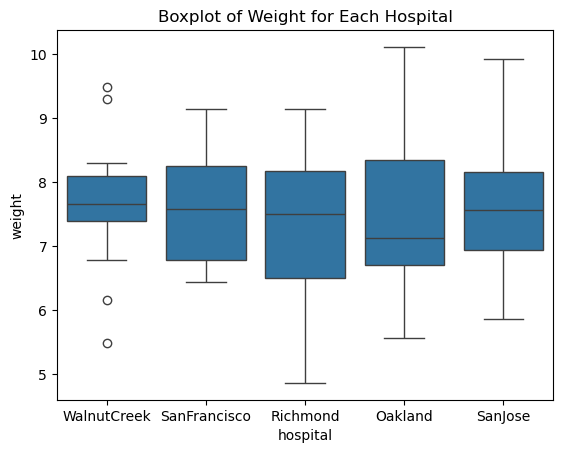

In [4]:
sns.boxplot(df, x='hospital', y='weight')
plt.title("Boxplot of Weight for Each Hospital")

>Boxplot of Weight for Each Hospital

>Oakland Hospital has the lowest overall birth weight.

### Question 1.3  
Create a set of 4 dummy variables that together code the hospital. Set Walnut Creek to be your comparison group. Run a multiple regression model with the 4 dummy variables as explanatory variables. Report the interecept and slope values. What do the intercept and slope values mean? 

In [5]:
df['Oak'] = np.double(df['hospital'] == 'Oakland')
df['SF'] = np.double(df['hospital'] == 'SanFrancisco')
df['SJ'] = np.double(df['hospital'] == 'SanJose')
df['Rich'] = np.double(df['hospital'] == 'Richmond')
b, R2 = fit_multReg(df, df['weight'], ['Oak', 'SF', 'SJ', 'Rich'], figure=False)
print(b)

[ 7.64577979 -0.2043533   0.02134188 -0.10127978 -0.33250686]


>The intercept indicates that the average birth weight for Walnut Creek Hospital is 7.65 lbs. The b1 indicates that the average birth weight for Oakland Hospital is 0.20 lbs lower than Walnut Creek. The b2 indicates that the average birth weight for SF is 0.02 lbs higher than Walnut Creek. The b3 indicates that the average birth weight for SJ is 0.10 lbs lower than Walnut Creek. The b4 indicates that the average birth weight for Richmond is 0.33 lbs lower than Walnut Creek.

## Task 2: Model selection for multiple regression 
### Question 2.1 
Write a version of the crossvalidation function that does K-fold crossvalidation and works specifically with multRegFit as the fitting function. 

KfoldCVmultReg(D,y,xname,K=20,fitfcn=multRegFit,param={},predictfcn=multRegPredict):
- D: Data Frame with explanatory variables  
- y: response variable 
- xname: List of explanatory variables
- K: Number of crossvalidation folds

For dividing the data up in K pieces, you can use the following trick to assign a partition index to each of the data-points:
```
#N = number of data points 
#K = number of test sets (folds)
ind = np.arange(N)
ind = np.floor(ind/N*K)
```


The code should compute and return the predictive (crossvalidated) $R^2$ (R2cv) and the fitted $R^2$ (R2). 
It should use the entries in the Dictionary to pass them to the function using `fitfcn(D,y,xname,**param)`
Run 20-fold crossvalidation on the multiple regression model, with birth weight as the response variable and 

- age of the mother 
- smoker (dummy coded) 
- birth occurred in Oakland? 
- gestation 

as explanatory variables. 
Report R2cv and R2. 

In [6]:
def KfoldCVmultReg(D,y,xname,K=20,fitfcn=fit_multReg,param={},predictfcn=multRegPredict):
    N = len(y)
    ind = np.arange(N)
    np.random.shuffle(ind)
    fold_ind = np.floor(ind/N*K)
    yp_cv = np.zeros(N)
    for i in range(K):
        train_ind = ind[fold_ind != i]
        test_ind = ind[fold_ind == i]
        b_fold, _ = fitfcn(D.iloc[train_ind], y.iloc[train_ind], xname, **param)
        yp_cv[test_ind] = predictfcn(b_fold, D.iloc[test_ind], xname)
        TSS = np.sum((y - np.mean(y))**2)
        RSS_cv = np.sum((y - yp_cv)**2)
        R2cv = 1 - (RSS_cv / TSS)
        b_full, R2 = fitfcn(D, y, xname, **param)
        return R2cv, R2
        
R2_cv, R2 = KfoldCVmultReg(df, df['weight'], ['age', 'smokeI', 'Oak', 'gestation'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
print(R2_cv)
print(R2)

-48.52326654230139
0.3560741562766847


### Question 2.2 
Using the R2cv from the 20-fold crossvalidation, determine the best predictive model for birthweight using the following candidate variables 

- age of mom
- smoker (dummy coded) 
- gestation 
- parity 

Start with the R2cv for the full model (Question 2.1)and use **backwards** step-wise regression to find the best model (the model that increases R2cv the most). Show all steps of your selection procedure. Report the formula of your best model. 

In [7]:
R2_cv1, R21 = KfoldCVmultReg(df, df['weight'], ['smokeI', 'gestation', 'parity'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
R2_cv2, R22 = KfoldCVmultReg(df, df['weight'], ['age', 'gestation', 'parity'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
R2_cv3, R23 = KfoldCVmultReg(df, df['weight'], ['age', 'smokeI', 'parity'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
R2_cv4, R24 = KfoldCVmultReg(df, df['weight'], ['age', 'smokeI', 'gestation'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
print(R2_cv1)
print(R2_cv2)
print(R2_cv3)
print(R2_cv4)
R2_cv5, R25 = KfoldCVmultReg(df, df['weight'], ['smokeI', 'gestation'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
R2_cv6, R26 = KfoldCVmultReg(df, df['weight'], ['age', 'gestation'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
R2_cv7, R27 = KfoldCVmultReg(df, df['weight'], ['age', 'smokeI'], K=20, fitfcn=fit_multReg, param={'figure': False}, predictfcn=multRegPredict)
print(R2_cv5)
print(R2_cv6)
print(R2_cv7)

-48.52657334059737
-48.527739933208935
-48.550305117969486
-48.523458904445135
-48.52746792278386
-48.52682476108548
-48.551037084287


>The best model is R2_cv4, weight = b0 + b1(age) + b2(smokeI) + b3(gestation).

## Task 3: Implement regularized regression to build a better predictive model 
In this task you will implement regularized regression to try to build a better predictive model for the birthweight of data. 
Like in Task 2, we will consider the following explanatory variables:

- age of the mother 
- smoker (dummy coded) 
- birth occurred in Oakland? 
- gestation 

### Question 3.1: Z-standardize the regressors 
Write a function `zstandardize`, which takes as an input a pandas series or ndarray 
and returns a z-standardized version of the data 

Use the function to z-standardize the columns age,gestation,parity, and smokeDummy. 

Create new columns in the data frame called ageZ,gestationZ,parityZ, and smokeDummyZ.

Check that the mean of the new variables in very close to and the std very close to 1.  

In [8]:
def zstandardize(data):
    z = (data - np.mean(data)) / np.std(data)
    return z
    
df['ageZ'] = zstandardize(df['age'])
df['gestationZ'] = zstandardize(df['gestation'])
df['parityZ'] = zstandardize(df['parity'])
df['smokeIZ'] = zstandardize(df['smokeI'])
print(np.mean(df['ageZ']))
print(np.mean(df['gestationZ']))
print(np.mean(df['parityZ']))
print(np.mean(df['smokeIZ']))
print(np.std(df['ageZ']))
print(np.std(df['gestationZ']))
print(np.std(df['parityZ']))
print(np.std(df['smokeIZ']))

7.69939667577546e-16
1.7741363933510002e-15
-3.7747582837255325e-17
1.4432899320127036e-17
1.0
1.0
1.0000000000000013
0.9999999999999994


### Question 3.2 Implement Ridge regression (L2 regularized regression) 

To implement ridge regression you need to modify our loss function. 
Make a copy of the function `RSSloss` from assigment 10. 
Rename it to `ridgeLoss`. Give the function an additional input parameter, namely alpha. Give this a default value of 1.0. 

Change the loss and the gradient to take into account the regularization. 

**Note that we are not regularizing the intercept regressor (b0)**

Overall the function should take the following input arguments:

    Args:
        b (nd.array): Array of regression coefficients - first is intercept 
        y (ndarray): Dependent variable
        predictfcn (function): Function that gives us the predicted values  
        args (tuple): Arguments to prediction function, here (D,xname,return_deriv)
        alpha (float): Regularization parameter 
        returnDeriv (bool): Whether to return gradient
    Returns:
        loss: Current loss
        grad: gradient of loss function in respect to parameters  (optional)

Then make a copy of `fit_RegFit` from above and rename it to `ridgeFit`. 
Again, you need to add an additional input parameter (alpha) to the function. 
Alpha needs to be passed to your loss function (`ridgeLoss`) when you call so.minimize: 

`so.minimize(ridgeLoss,b0,args=(y,multRegPredict,(D,xname),alpha,True),jac=True)`

You need to take care when you calculate R2 of the fit - Since ridgeLoss does not return the 
residual-sum-of-squares, but adds the ridge loss, you need to use the appropriate function to calculate the RSS.

To test your function:
* Use it to fit a model that explains weight with the explanatory variables `['ageZ','smokeDummyZ','gestationZ','parityZ']`. Note: use the zstandardized version of the variables.  
* Do the fit setting `alpha=0` and `alpha=8`, and report both R2 and the regression coefficients (b)
* Compare the R2 between the two settings of alpha. Also compare to the one found for normal multiple regression (Question 2.1). What do you see and why?
* Compare the regression weights (b) between the two settings of alpha. which regression weights changed and why? 


In [9]:
def ridgeLoss(b,y,predictfcn,args=(), alpha=1, returnDeriv=False):
    if (returnDeriv):
        predY,deriv = predictfcn(b,*args,returnDeriv=True)
        res = np.array(y-predY)
        rss = sum(res**2)
        penalty = alpha * np.sum(b[1:]**2)
        loss = rss + penalty
        grad = -2 * np.sum(res.reshape(-1,1) * deriv,axis=0)
        penalty_grad = 2 * alpha * b
        penalty_grad[0] = 0 
        grad += penalty_grad
        return loss, grad
    predY = predictfcn(b,*args)
    res = np.array(y-predY)
    rss = sum(res**2)
    penalty = alpha * np.sum(b[1:]**2)
    loss = rss + penalty
    return loss

def ridgeFit(D,y,xname=[], alpha=1, figure=False,b0=[]):
    k=len(xname)+1
    if (len(b0)!=k):
        b0=np.zeros((k,))
    RES = so.minimize(ridgeLoss,b0,args=(y,multRegPredict,(D,xname),alpha,True),jac=True)
    b=RES.x 
    TSS = sum((y-np.mean(y))**2)
    yp = multRegPredict(b,D,xname)
    RSS = sum((y-yp)**2)
    R2 = 1-RSS/TSS
    return (b,R2)

b1, R21 = ridgeFit(df, df['weight'], ['ageZ', 'smokeIZ', 'gestationZ', 'parityZ'], alpha=0)
print(b1)
print(R21)
b2, R22 = ridgeFit(df, df['weight'], ['ageZ', 'smokeIZ', 'gestationZ', 'parityZ'], alpha=8)
print(b2)
print(R22)

[ 7.49494802e+00 -1.03658041e-01 -3.80594550e-01  4.31717525e-01
  4.15804617e-03]
0.3503171176870481
[ 7.49494804e+00 -9.39389521e-02 -3.55989002e-01  4.03196759e-01
  3.18311907e-03]
0.34878644202475884


>The R2 for the normal multiple regression is slightly larger than the R2 when alpha=0. The R2 when alpha=8 has the lowest R2. The R2 decreases because ridge regression adds bias to prevent overfitting which reduces how good the fit is in order to lower variance. The intercept stays the same for both, but the ageZ decreases for alpha=8, smokeIZ increases slightly for alpha=8, gestationZ decreases slightly for alpha=8, and parityZ decreases slightly for alpha=8. The slopes are smaller for alpha=8 because the penalty term penalizes large coefficients, so variables that are less predictive such as ageZ, gestationZ, and parityZ will shrink more compared to alpha=0.

### Question 3.3: Crossvalidate Ridge regression 
Copy your function `KfoldCVmultReg` from Question 2.1, rename it to `KfoldCVridge`, and modify it to work with Ridge regression. 
That means it needs to take an additional input parameter `alpha` that it passes on to the fitting function. 

To calculate the R2 and R2cv for the model of `weight` using the explanatory variables `['ageZ','smokeDummyZ','gestationZ','parityZ']`. Like in question 3.2, use the standardized versions of the variables and try both the setting `alpha=0` and `alpha=8`. 

How to the R2 and R2cv values compare between the two settings of alpha? Do you get better predictive performance than the reduced model that you found using feature selection (Question 2.2)?


*Note: If you want, play a bit with the regularization parameter to see if you can find a better setting. What happens when you make `alpha` very large (i.e. 1000)? (this is optional, but educational)*

In [10]:
def KfoldCVridge(D,y,xname,K=20,alpha=1,fitfcn=ridgeFit,param={},predictfcn=multRegPredict):
    N = len(y)
    ind = np.arange(N)
    np.random.shuffle(ind)
    fold_ind = np.floor(ind/N*K)
    yp_cv = np.zeros(N)
    for i in range(K):
        train_ind = ind[fold_ind != i]
        test_ind = ind[fold_ind == i]
        b_fold, _ = fitfcn(D.iloc[train_ind], y.iloc[train_ind], xname, alpha)
        yp_cv[test_ind] = predictfcn(b_fold, D.iloc[test_ind], xname)
        TSS = np.sum((y - np.mean(y))**2)
        RSS_cv = np.sum((y - yp_cv)**2)
        R2cv = 1 - (RSS_cv / TSS)
        _, R2 = fitfcn(D, y, xname, alpha)
        return R2cv, R2

R2_cv1, R21 = KfoldCVridge(df, df['weight'], ['ageZ', 'smokeIZ', 'gestationZ', 'parityZ'], K=20, alpha=0, fitfcn=ridgeFit, param={}, predictfcn=multRegPredict)
R2_cv2, R22 = KfoldCVridge(df, df['weight'], ['ageZ', 'smokeIZ', 'gestationZ', 'parityZ'], K=20, alpha=8, fitfcn=ridgeFit, param={}, predictfcn=multRegPredict)
print(R2_cv1)
print(R21)
print(R2_cv2)
print(R22)

-48.52345369290771
0.3503171176870481
-48.52506704224325
0.34878644202475884


>The R2_cv and the R2 for alpha=8 is slightly lower than the alpha=0 and also slightly lower than feature selection. Yes, the predictive performance is better than the reduced model found using feature selection.

## Task 4: Use logistic regression to predict complications 
In this task you will create and test a logistic regression model that predicts the presence of a complication in the first three month (0: no complication, 1: complication). 

** Task 4 of the Homework does not have to be handed in and will not be graded! It is only added here to provide additional preparation and practice for you for the final. So if you are short on time, leave these questions open and solve them when you practice for the final.**

We have added the logistic regression functions `fit_logisticReg`, `logisticRegPredict`, `logisticLoss` to the notebook already. 

### Question 4.2: Crossvalidation of logistic models
Modify the KfoldCVmultReg function to make it work for logistic regression. As before, use K-fold crossvalidation. The main changes are that 
- you need to use logisticRegFit and logisticRegPredict as fitfcn and predictfcn respectively. 
- To save time, initialize each optimization with from the parameters that you found on the entire data by setting `b_init` 
- instead of the crossvalidated R2, your function should return the crossvalidated log-likelihood and non-crossvalidated log-likelihood. 

Using your function, calculate the the difference in crossvalidated log-likelihood for the model that predicts complications with an intercept only (b0) and a model that predicts complications with an intercept and smokeDummy. 
From the difference, report the Bayes-Factor between the two models. What do you conclude? 

### Question 4.3:
Compare the model that uses only intercept, smoking as explanatory variable to one that uses: 

 * intercept, smoking, weight 
 * intercept, smoking, age 
 * intercept, smoking, weight, age 
 
Report the cross-validated Log-likelihood for each model. Which one is the best model? 

### Question 4.4 : 
In the model (['smokeDummy','weight']), how do each of the explanatory variables contribute to the chance of complication? That is, for each variable, would an increase in the variable lead to an increased or decreased probability of a complication? 

What reduction in birth weight causes the same amount of risk of complication as having a smoking mother?  